In [66]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mmoreaux_audio_cats_and_dogs_path = kagglehub.dataset_download('mmoreaux/audio-cats-and-dogs')
emrahaydemr_gunshot_audio_dataset_path = kagglehub.dataset_download('emrahaydemr/gunshot-audio-dataset')

print('Data source import complete.')


Data source import complete.


# ***Cat-Dog Recognition***

In [67]:
!pip install noisereduce

In [68]:
import os
import librosa
import librosa.display
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import noisereduce as nr
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from PIL import Image
import IPython.display as ipd

# **Load Audio**

In [69]:
audio_eg = "/kaggle/input/audio-cats-and-dogs/cats_dogs/train/cat/cat_119.wav"
ipd.Audio(audio_eg)

In [70]:
y, sr = librosa.load(audio_eg)

In [71]:
# Get basic information about the audio
print(f"Audio Length: {len(y) / sr} seconds")
print(f"Sample Rate: {sr}")
print(f"Audio Shape: {y.shape}")

# Calculate some basic statistics
print(f"Mean: {np.mean(y)}")
print(f"Standard Deviation: {np.std(y)}")
print(f"Min: {np.min(y)}")
print(f"Max: {np.max(y)}")

Audio Length: 4.316009070294784 seconds
Sample Rate: 22050
Audio Shape: (95168,)
Mean: 0.000960113771725446
Standard Deviation: 0.22055278718471527
Min: -0.9777283668518066
Max: 1.0269981622695923


# **Plot the Spectrogram**

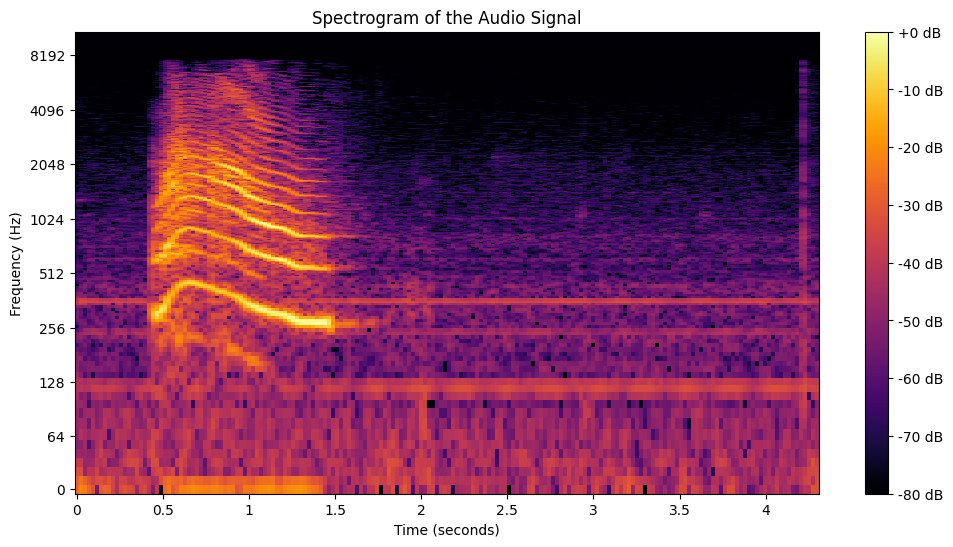

In [72]:
# Compute the Spectrogram
S = librosa.stft(y)  # Compute Short-Time Fourier Transform (STFT)
D = librosa.amplitude_to_db(np.abs(S), ref=np.max)  # Take magnitude (absolute value) before converting to dB

# Plot the Spectrogram
plt.figure(figsize=(12, 6))
librosa.display.specshow(D, x_axis='time', y_axis='log', sr=sr, cmap='inferno')
plt.title("Spectrogram of the Audio Signal")
plt.colorbar(format='%+2.0f dB')
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()

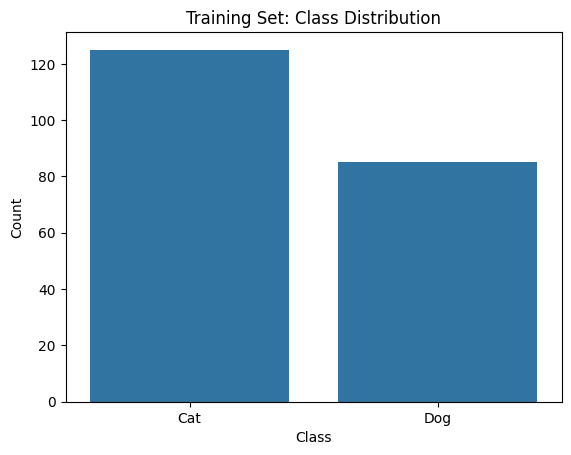

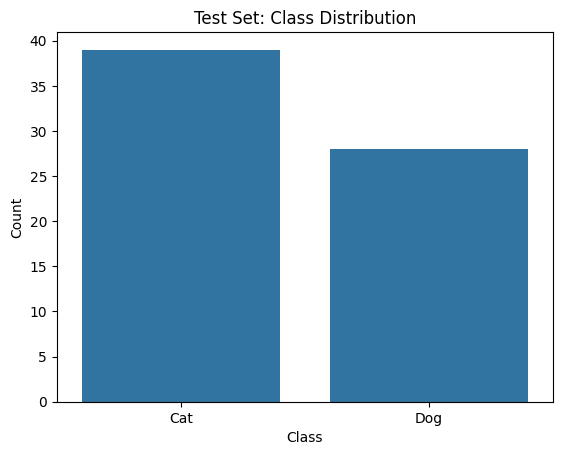

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Combine labels
label_names = {0: 'Cat', 1: 'Dog'}
train_labels_named = [label_names[i] for i in y_train]
test_labels_named = [label_names[i] for i in y_test]

# Plot class distribution
sns.countplot(x=train_labels_named)
plt.title("Training Set: Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

sns.countplot(x=test_labels_named)
plt.title("Test Set: Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# **Feature Extraction**

In [74]:
def extract_features_from_directory(directory_path, label):
    features = []
    labels = []

    for file in os.listdir(directory_path):
        if file.endswith('.wav'):
            try:
                file_path = os.path.join(directory_path, file)
                y_audio, sr = librosa.load(file_path, sr=None)
                y_audio = nr.reduce_noise(y=y_audio, sr=sr)
                y_trimmed, _ = librosa.effects.trim(y_audio)
                y_normalized = y_trimmed / max(abs(y_trimmed))
                mfccs = librosa.feature.mfcc(y=y_normalized, sr=sr, n_mfcc=13)
                spectral_centroids = librosa.feature.spectral_centroid(y=y_normalized, sr=sr)
                spectral_rolloff = librosa.feature.spectral_rolloff(y=y_normalized, sr=sr)

                mfccs_mean = np.mean(mfccs, axis=1)
                mfccs_std = np.std(mfccs, axis=1)
                mfccs_min = np.min(mfccs, axis=1)
                mfccs_max = np.max(mfccs, axis=1)
                centroid_mean = np.mean(spectral_centroids)
                centroid_std = np.std(spectral_centroids)
                centroid_min = np.min(spectral_centroids)
                centroid_max = np.max(spectral_centroids)
                rolloff_mean = np.mean(spectral_rolloff)
                rolloff_std = np.std(spectral_rolloff)
                vector = np.hstack([mfccs_mean, mfccs_std, mfccs_min, mfccs_max])
                vector = np.hstack([vector, centroid_mean, centroid_std, centroid_min, centroid_max])
                vector = np.hstack([vector, rolloff_mean, rolloff_std])


                features.append(vector)
                labels.append(label)
            except Exception as e:
                print(f"Error processing {file}: {e}")

    return features, labels

In [75]:
# Train data
train_cat_path = "/kaggle/input/audio-cats-and-dogs/cats_dogs/train/cat"
train_dog_path = "/kaggle/input/audio-cats-and-dogs/cats_dogs/train/dog"
X_cat_train, y_cat_train = extract_features_from_directory(train_cat_path, label=0)
X_dog_train, y_dog_train = extract_features_from_directory(train_dog_path, label=1)

X_train = np.array(X_cat_train + X_dog_train)
y_train = np.array(y_cat_train + y_dog_train)

# Test data
test_cat_path = "/kaggle/input/audio-cats-and-dogs/cats_dogs/test/cats"
test_dog_path = "/kaggle/input/audio-cats-and-dogs/cats_dogs/test/test"
X_cat_test, y_cat_test = extract_features_from_directory(test_cat_path, label=0)
X_dog_test, y_dog_test = extract_features_from_directory(test_dog_path, label=1)

X_test = np.array(X_cat_test + X_dog_test)
y_test = np.array(y_cat_test + y_dog_test)


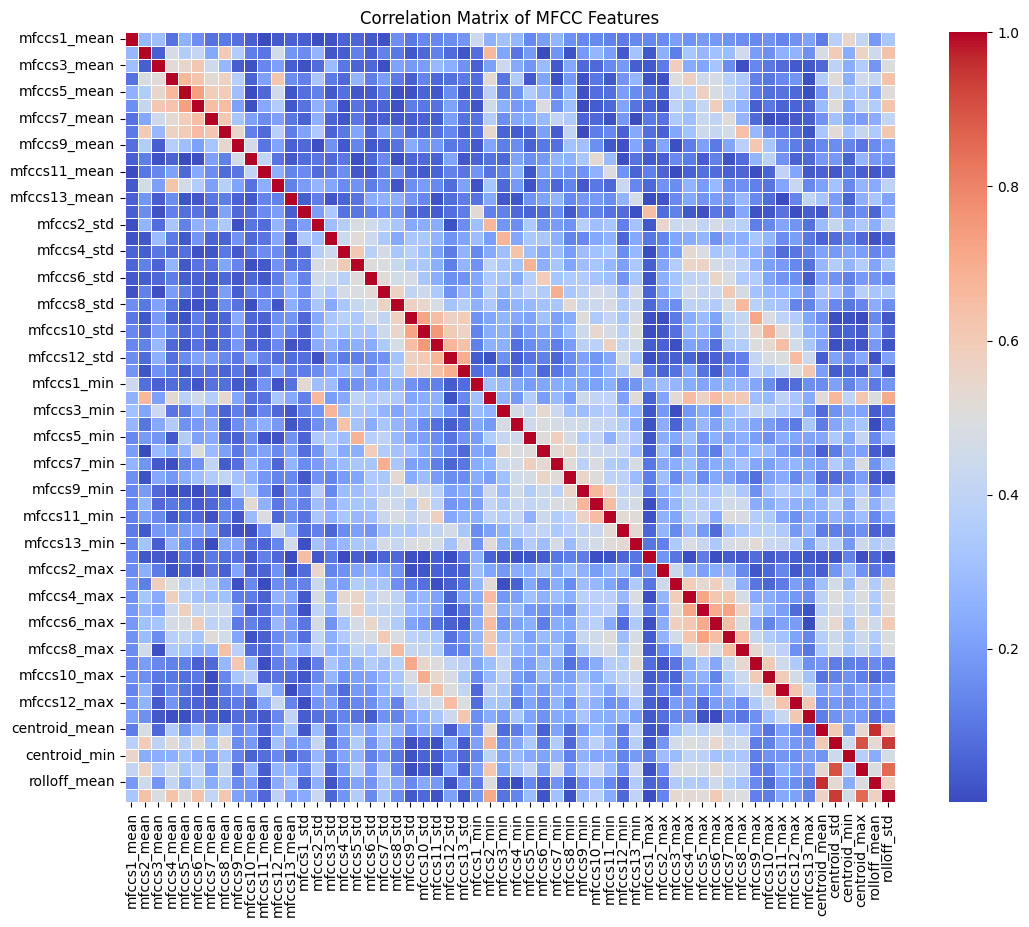

Original feature count: 58
Removed due to high correlation: 3
Remaining features: 55
Selected features: ['mfccs1_mean', 'mfccs2_mean', 'mfccs3_mean', 'mfccs4_mean', 'mfccs5_mean', 'mfccs6_mean', 'mfccs7_mean', 'mfccs8_mean', 'mfccs9_mean', 'mfccs10_mean', 'mfccs11_mean', 'mfccs12_mean', 'mfccs13_mean', 'mfccs1_std', 'mfccs2_std', 'mfccs3_std', 'mfccs4_std', 'mfccs5_std', 'mfccs6_std', 'mfccs7_std', 'mfccs8_std', 'mfccs9_std', 'mfccs10_std', 'mfccs11_std', 'mfccs12_std', 'mfccs13_std', 'mfccs1_min', 'mfccs2_min', 'mfccs3_min', 'mfccs4_min', 'mfccs5_min', 'mfccs6_min', 'mfccs7_min', 'mfccs8_min', 'mfccs9_min', 'mfccs10_min', 'mfccs11_min', 'mfccs12_min', 'mfccs13_min', 'mfccs1_max', 'mfccs2_max', 'mfccs3_max', 'mfccs4_max', 'mfccs5_max', 'mfccs6_max', 'mfccs7_max', 'mfccs8_max', 'mfccs9_max', 'mfccs10_max', 'mfccs11_max', 'mfccs12_max', 'mfccs13_max', 'centroid_mean', 'centroid_std', 'centroid_min']


In [76]:
# 2️⃣ Create DataFrame with feature names
feature_names = [f"mfccs{i+1}_{stat}" for stat in ['mean', 'std', 'min', 'max'] for i in range(13)]
feature_names += [f"centroid_{stat}" for stat in ['mean', 'std', 'min', 'max']]
feature_names += [f"rolloff_{stat}" for stat in ['mean', 'std']]
df = pd.DataFrame(X_train, columns=feature_names)

# 3️⃣ Compute correlation matrix
corr_matrix = df.corr().abs()

# 4️⃣ Visualize (optional)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Matrix of MFCC Features")
plt.show()

# 5️⃣ Drop highly correlated features (threshold > 0.9)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

# 6️⃣ Reduced feature set
df_reduced = df.drop(columns=to_drop)
X_reduced = df_reduced.values

print(f"Original feature count: {df.shape[1]}")
print(f"Removed due to high correlation: {len(to_drop)}")
print(f"Remaining features: {X_reduced.shape[1]}")
print("Selected features:", df_reduced.columns.tolist())

In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100,'%')
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 91.04477611940298 %

Classification Report:
               precision    recall  f1-score   support

         Cat       0.87      1.00      0.93        39
         Dog       1.00      0.79      0.88        28

    accuracy                           0.91        67
   macro avg       0.93      0.89      0.90        67
weighted avg       0.92      0.91      0.91        67


Confusion Matrix:
 [[39  0]
 [ 6 22]]


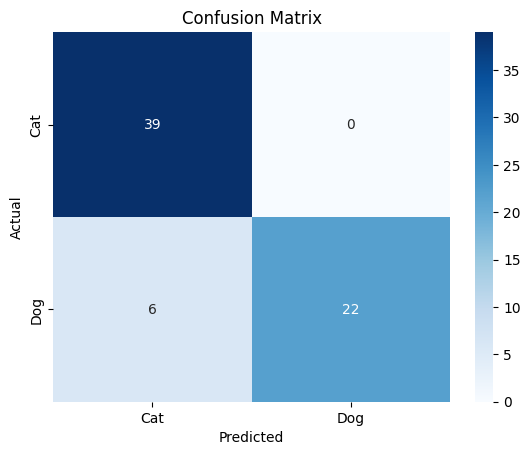

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [80]:
import random

def random_predict(model, X_test, y_test, scaler):
    # Randomly select an index from the test set
    random_idx = random.randint(0, len(X_test) - 1)

    # Select the sample and its corresponding true label
    sample = X_test[random_idx].reshape(1, -1)
    true_label = y_test[random_idx]

    # Scale the sample using the same scaler as the training data
    sample_scaled = scaler.transform(sample)

    # Predict the label using the trained model
    predicted_label = model.predict(sample_scaled)[0]

    # Map label to corresponding class name
    class_names = ["Cat", "Dog"]

    # Display the prediction and the actual result
    print(f"Sample Index: {random_idx}")
    print(f"Predicted Label: {class_names[predicted_label]}")
    print(f"True Label: {class_names[true_label]}")

    # Optionally, you can also print the raw feature vector
    print(f"Sample Features: {sample[0]}")

# Example of usage:
random_predict(model, X_test, y_test, scaler)


Sample Index: 42
Predicted Label: Dog
True Label: Dog
Sample Features: [-386.31439209   85.65836334  -14.86107731  -23.28104973  -15.9474535
  -19.17184448  -15.06624985  -19.85244942   -8.19009781    1.54261339
   -4.8832531    -6.67133045    4.27690935  128.09837341   45.16533661
   50.35026932   27.28264427   12.04850483   17.03156471   15.17211056
   15.58589077   13.16957664   13.80132675    9.91175842   12.5885973
   11.2163744  -502.35266113   25.47578621 -136.52572632  -77.47615051
  -51.05681992  -64.26422119  -54.75944519  -56.33940125  -34.7967186
  -19.66475296  -33.44996643  -41.22503662  -19.00738907  -59.06987
  169.43804932   54.09241486   21.77595139   18.81508446    6.89853477
    8.32554245   11.29568291   33.67739487   32.09519196   23.2754612
   26.26021576   34.23571396  790.87993612  286.25783821  295.40187476
 1414.5849321  1170.08739407  464.59516683]
